In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
from statsmodels.graphics.gofplots import qqplot # quantile

from scipy.stats import norm
from scipy.stats import ttest_ind, ttest_rel
from scipy.stats import levene
from scipy.stats import shapiro, kstest # To check Gaussian

# Height and Weight

In [2]:
df_hw = pd.read_csv("weight-height.csv")

In [3]:
df_hw.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
height = df_hw["Height"]

<AxesSubplot:xlabel='Height', ylabel='Count'>

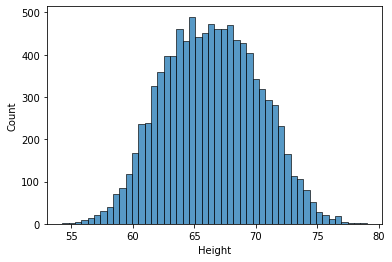

In [5]:
sns.histplot(height)

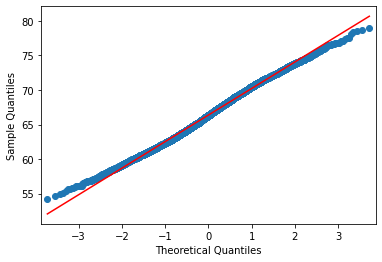

In [8]:
# QQ plot - just a visual way of confirming
qqplot(height, line="s")
plt.show()
# If the points lie close to the line, then you can Gaussian

In [14]:
height.shape

(10000,)

In [15]:
# Shapiro is best in the 50 to 200 range
height_subset = height.sample(100)

In [16]:
# H0: Data is Gaussian
# Ha: Data is not Gaussian
test_stat, p_value = shapiro(height_subset)
print(p_value)
if p_value < 0.05:
    print("Reject H0")
    print("Data is not Gaussian")
else:
    print("Fail to reject H0")
    print("Data is Gaussian")

0.7307180762290955
Fail to reject H0
Data is Gaussian


In [20]:
# H0: Data is Gaussian
# Ha: Data is not Gaussian
mu = height_subset.mean()
sigma = height_subset.std()

test_stat, p_value = kstest(
    height_subset,
    norm.cdf,
    args=(mu, sigma)
)
print(p_value)
if p_value < 0.05:
    print("Reject H0")
    print("Data is not Gaussian")
else:
    print("Fail to reject H0")
    print("Data is Gaussian")

0.8373363527567355
Fail to reject H0
Data is Gaussian


## Variance

<AxesSubplot:xlabel='Height', ylabel='Count'>

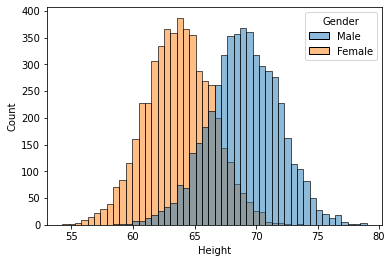

In [21]:
sns.histplot(data=df_hw, x="Height", hue="Gender")

In [22]:
height_men = df_hw[df_hw["Gender"]=="Male"]["Height"]
height_women = df_hw[df_hw["Gender"]=="Female"]["Height"]

In [23]:
height_men.mean()

69.02634590621741

In [24]:
height_women.mean()

63.70877360342507

In [27]:
# H0: Men and women has same average height (high p-value)
# Ha: Different height (low p-value)
ttest_ind(height_men, height_women)

Ttest_indResult(statistic=95.60271449148823, pvalue=0.0)

When we do T-test, we only compare mean

Next question: How do we compare std dev (variance)

In [28]:
height_men.var()

8.198843252520467

In [29]:
height_women.var()

7.2699474936701245

In [31]:
len(height_men)

5000

In [32]:
len(height_women)

5000

In [33]:
# H0: same variance
# Ha: variance is different
test_stat, p_value = levene(height_men, height_women)
print(p_value)
if p_value < 0.05:
    print("Reject H0")
    print("Variances are different")
else:
    print("Fail to reject H0")
    print("Variances are the same")

0.0004586349895436178
Reject H0
Variances are different


# Waiting time

In [9]:
df_wt = pd.read_csv("waiting_time.csv")

In [10]:
df_wt.head()

,time
0,184.003075
1,36.721521
2,29.970417
3,75.640285
4,61.489439


<AxesSubplot:xlabel='time', ylabel='Count'>

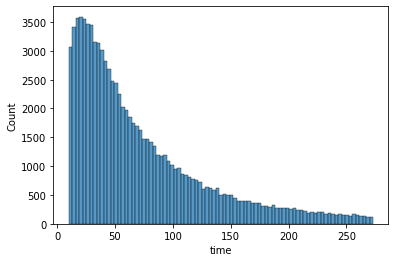

In [11]:
sns.histplot(df_wt["time"])

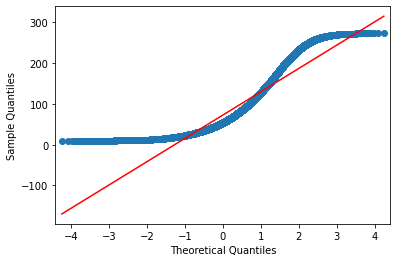

In [12]:
qqplot(df_wt["time"], line="s")
plt.show()

# Problem solving session

In [34]:
df_ps = pd.read_csv("problem_solving.csv")

In [35]:
df_ps.head(20)

,id,test_1,test_2
0,0,40,38
1,1,49,44
2,2,65,69
3,3,59,63
4,4,44,43
5,5,39,43
6,6,87,93
7,7,66,73
8,8,60,66
9,9,63,67


In [38]:
df_ps.describe()

,id,test_1,test_2
count,137.000000,137.000000,137.000000
mean,68.000000,60.489051,62.430657
std,39.692569,17.080311,17.516293
min,0.000000,30.000000,27.000000
25%,34.000000,46.000000,48.000000
50%,68.000000,59.000000,62.000000
75%,102.000000,75.000000,77.000000
max,136.000000,89.000000,96.000000


In [37]:
ttest_rel(df_ps["test_1"], df_ps["test_2"])

TtestResult(statistic=-5.502886353508166, pvalue=1.795840353792307e-07, df=136)